# Obtain beta cells

- extract beta cells in db/db model

In [1]:
import scanpy as sc

adata=sc.read_h5ad('pancreas_cells.h5ad')

adata

AnnData object with n_obs × n_vars = 301796 × 31334
    obs: 'batch_integration', 'dataset', 'design', 'cell_cycle_phase', 'ins_high', 'gcg_high', 'sst_high', 'ppy_high', 'cell_filtering', 'strain', 'age', 'cell_type_originalDataset_unified', 'cell_type_originalDataset', 'cell_type_reannotatedIntegrated', 'n_genes', 'mt_frac', 'doublet_score', 'log10_n_counts', 'age_approxDays', 'dataset__design__sample', 'cell_subtype_immune_reannotatedIntegrated', 'cell_subtype_endothelial_reannotatedIntegrated', 'emptyDrops_LogProb_scaled', 'cell_subtype_beta_coarse_reannotatedIntegrated', 'cell_subtype_beta_fine_reannotatedIntegrated', 'GP_1', 'GP_2', 'GP_3', 'GP_4', 'GP_5', 'GP_6', 'GP_7', 'GP_8', 'GP_9', 'GP_10', 'GP_11', 'GP_12', 'GP_13', 'GP_14', 'GP_15', 'GP_16', 'GP_17', 'GP_18', 'GP_19', 'GP_20', 'GP_21', 'GP_22', 'GP_23', 'GP_24', 'GP_25', 'GP_26', 'GP_27', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'diabetes_model', 'chemical_stress', 'GEO

In [ ]:
db_adata=adata[adata.obs['age']=='16-18 w']


View of AnnData object with n_obs × n_vars = 69745 × 31334
    obs: 'batch_integration', 'dataset', 'design', 'cell_cycle_phase', 'ins_high', 'gcg_high', 'sst_high', 'ppy_high', 'cell_filtering', 'strain', 'age', 'cell_type_originalDataset_unified', 'cell_type_originalDataset', 'cell_type_reannotatedIntegrated', 'n_genes', 'mt_frac', 'doublet_score', 'log10_n_counts', 'age_approxDays', 'dataset__design__sample', 'cell_subtype_immune_reannotatedIntegrated', 'cell_subtype_endothelial_reannotatedIntegrated', 'emptyDrops_LogProb_scaled', 'cell_subtype_beta_coarse_reannotatedIntegrated', 'cell_subtype_beta_fine_reannotatedIntegrated', 'GP_1', 'GP_2', 'GP_3', 'GP_4', 'GP_5', 'GP_6', 'GP_7', 'GP_8', 'GP_9', 'GP_10', 'GP_11', 'GP_12', 'GP_13', 'GP_14', 'GP_15', 'GP_16', 'GP_17', 'GP_18', 'GP_19', 'GP_20', 'GP_21', 'GP_22', 'GP_23', 'GP_24', 'GP_25', 'GP_26', 'GP_27', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'diabetes_model', 'chemical_stress

In [7]:
sc.pp.highly_variable_genes(db_adata, n_top_genes=2000,subset=True)

/disk/tanbowen/anaconda3/envs/knockpath/lib/python3.11/site-packages/scanpy/preprocessing/_highly_variable_genes.py:664: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}


In [22]:
db_adata.obs['cell_type']=db_adata.obs['cell_type_reannotatedIntegrated']
db_adata.obs['cell_type'].value_counts()

cell_type
beta             31983
immune           13369
alpha             6587
delta             4641
endothelial       2977
ductal            2906
stellate a.       2693
gamma             1209
stellate q.       1005
beta+delta         828
lowQ               408
acinar             326
alpha+delta        286
beta+gamma         182
endo. prolif.      146
delta+gamma         74
schwann             45
E non-endo.         40
alpha+beta          34
E endo.              6
Name: count, dtype: int64

In [12]:
db_adata.obs['diabetes_model']

index
CTTCCTTGTACCCAGC-1-MUC13640-VSG         T2D_db/db-treated_VSG
GTGCTTCCATTGCCTC-1-MUC13631-VSG    T2D_db/db-treated_PairFeed
ATAGGCTCATGCAGCC-1-MUC13639-VSG                     T2D_db/db
TACCTGCAGGAAAGGT-1-MUC13640-VSG         T2D_db/db-treated_VSG
TCGGATAGTAACCCGC-1-MUC13641-VSG                     T2D_db/db
                                              ...            
CCCTTAGTCGGAATGG-1-MUC13640-VSG         T2D_db/db-treated_VSG
CCCTTAGAGACAACAT-1-MUC13642-VSG         T2D_db/db-treated_VSG
AAATGGATCACCTCGT-1-MUC13631-VSG    T2D_db/db-treated_PairFeed
GTAGAAAAGACGGTCA-1-MUC13632-VSG    T2D_db/db-treated_PairFeed
ATGAGGGCATTCCTCG-1-MUC13632-VSG    T2D_db/db-treated_PairFeed
Name: diabetes_model, Length: 69745, dtype: category
Categories (3, object): ['T2D_db/db', 'T2D_db/db-treated_PairFeed', 'T2D_db/db-treated_VSG']

In [18]:
import pandas as pd
pd.isnull(db_adata.obs['diabetes_model'])

db_adata.obs['diabetes_model']=db_adata.obs['diabetes_model'].astype(str)

db_adata.obs['diabetes_model'][db_adata.obs['diabetes_model']=='nan']='Healthy'

/tmp/ipykernel_2404448/192848876.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  db_adata.obs['diabetes_model'][db_adata.obs['diabetes_model']=='nan']='Healthy'
/tmp/ipykernel_2404448/192848876.py:6: SettingWithCopyWarning: 
A value is t

In [ ]:
db_adata.obs['diabetes_model'].value_counts()


diabetes_model
T2D_db/db-treated_PairFeed    23134
T2D_db/db                     18230
T2D_db/db-treated_VSG         17226
Healthy                       11155
Name: count, dtype: int64

In [24]:
db_adata.obs['diabetes_model'] = db_adata.obs['diabetes_model'].str.replace('db/db', 'dbdb', regex=False)
db_adata.obs['diabetes_model']

index
CTTCCTTGTACCCAGC-1-MUC13640-VSG         T2D_dbdb-treated_VSG
GTGCTTCCATTGCCTC-1-MUC13631-VSG    T2D_dbdb-treated_PairFeed
ATAGGCTCATGCAGCC-1-MUC13639-VSG                     T2D_dbdb
TACCTGCAGGAAAGGT-1-MUC13640-VSG         T2D_dbdb-treated_VSG
TCGGATAGTAACCCGC-1-MUC13641-VSG                     T2D_dbdb
                                             ...            
CCCTTAGTCGGAATGG-1-MUC13640-VSG         T2D_dbdb-treated_VSG
CCCTTAGAGACAACAT-1-MUC13642-VSG         T2D_dbdb-treated_VSG
AAATGGATCACCTCGT-1-MUC13631-VSG    T2D_dbdb-treated_PairFeed
GTAGAAAAGACGGTCA-1-MUC13632-VSG    T2D_dbdb-treated_PairFeed
ATGAGGGCATTCCTCG-1-MUC13632-VSG    T2D_dbdb-treated_PairFeed
Name: diabetes_model, Length: 69745, dtype: object

In [25]:
db_adata.write_h5ad('db_pancreas_cells.h5ad')

- QC
- log-norm
- hvg

In [ ]:
adata.obs['cell_type'].value_counts(),adata.obs['cell_type_reannotatedIntegrated'].value_counts(),adata.obs['cell_type_originalDataset'].value_counts()

(cell_type
 type B pancreatic cell       102143
 pancreatic A cell             40935
 native cell                   36925
 hematopoietic cell            31703
 pancreatic D cell             24775
 pancreatic stellate cell      23302
 endothelial cell              13469
 pancreatic endocrine cell     10853
 pancreatic ductal cell         8742
 pancreatic PP cell             6999
 cell                            853
 Schwann cell                    617
 pancreatic acinar cell          480
 Name: count, dtype: int64,
 cell_type_reannotatedIntegrated
 beta             102143
 alpha             40935
 immune            31703
 E non-endo.       29177
 delta             24775
 stellate a.       18332
 endothelial       13469
 ductal             8742
 E endo.            7748
 gamma              6999
 beta+delta         5104
 stellate q.        4970
 alpha+delta        1901
 beta+gamma         1209
 delta+gamma        1069
 endo. prolif.       887
 lowQ                853
 alpha+beta          6

In [13]:
adata.obs_keys

db_beta_adata=adata[(adata.obs['cell_type_reannotatedIntegrated']=='beta') & (adata.obs['age']=='16-18 w')]

db_beta_adata

View of AnnData object with n_obs × n_vars = 31983 × 31334
    obs: 'batch_integration', 'dataset', 'design', 'cell_cycle_phase', 'ins_high', 'gcg_high', 'sst_high', 'ppy_high', 'cell_filtering', 'strain', 'age', 'cell_type_originalDataset_unified', 'cell_type_originalDataset', 'cell_type_reannotatedIntegrated', 'n_genes', 'mt_frac', 'doublet_score', 'log10_n_counts', 'age_approxDays', 'dataset__design__sample', 'cell_subtype_immune_reannotatedIntegrated', 'cell_subtype_endothelial_reannotatedIntegrated', 'emptyDrops_LogProb_scaled', 'cell_subtype_beta_coarse_reannotatedIntegrated', 'cell_subtype_beta_fine_reannotatedIntegrated', 'GP_1', 'GP_2', 'GP_3', 'GP_4', 'GP_5', 'GP_6', 'GP_7', 'GP_8', 'GP_9', 'GP_10', 'GP_11', 'GP_12', 'GP_13', 'GP_14', 'GP_15', 'GP_16', 'GP_17', 'GP_18', 'GP_19', 'GP_20', 'GP_21', 'GP_22', 'GP_23', 'GP_24', 'GP_25', 'GP_26', 'GP_27', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'diabetes_model', 'chemical_stress

In [16]:
db_beta_adata.write_h5ad('db_beta_cells.h5ad')

In [15]:
db_beta_adata.obs['diabetes_model'].value_counts(),db_beta_adata.obs['diabetes_model'].shape

#7609 healthy cells

(diabetes_model
 T2D_db/db-treated_VSG         10018
 T2D_db/db-treated_PairFeed     8995
 T2D_db/db                      5264
 Name: count, dtype: int64,
 (31983,))

# Obtain Alpha Cells

In [2]:
# Extract alpha cells in db/db model
import scanpy as sc

adata=sc.read_h5ad('pancreas_cells.h5ad')

db_alpha_adata = adata[(adata.obs['cell_type_reannotatedIntegrated'] == 'alpha') & (adata.obs['age'] == '16-18 w')]

db_alpha_adata

View of AnnData object with n_obs × n_vars = 6587 × 31334
    obs: 'batch_integration', 'dataset', 'design', 'cell_cycle_phase', 'ins_high', 'gcg_high', 'sst_high', 'ppy_high', 'cell_filtering', 'strain', 'age', 'cell_type_originalDataset_unified', 'cell_type_originalDataset', 'cell_type_reannotatedIntegrated', 'n_genes', 'mt_frac', 'doublet_score', 'log10_n_counts', 'age_approxDays', 'dataset__design__sample', 'cell_subtype_immune_reannotatedIntegrated', 'cell_subtype_endothelial_reannotatedIntegrated', 'emptyDrops_LogProb_scaled', 'cell_subtype_beta_coarse_reannotatedIntegrated', 'cell_subtype_beta_fine_reannotatedIntegrated', 'GP_1', 'GP_2', 'GP_3', 'GP_4', 'GP_5', 'GP_6', 'GP_7', 'GP_8', 'GP_9', 'GP_10', 'GP_11', 'GP_12', 'GP_13', 'GP_14', 'GP_15', 'GP_16', 'GP_17', 'GP_18', 'GP_19', 'GP_20', 'GP_21', 'GP_22', 'GP_23', 'GP_24', 'GP_25', 'GP_26', 'GP_27', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'diabetes_model', 'chemical_stress'

In [3]:
db_alpha_adata.write_h5ad('db_alpha_cells.h5ad')

## examine the heterogenity
permutation of diabetes model

In [1]:
import scanpy as sc
adata=sc.read_h5ad('db_pancreas_cells.h5ad')
adata

AnnData object with n_obs × n_vars = 69745 × 2000
    obs: 'batch_integration', 'dataset', 'design', 'cell_cycle_phase', 'ins_high', 'gcg_high', 'sst_high', 'ppy_high', 'cell_filtering', 'strain', 'age', 'cell_type_originalDataset_unified', 'cell_type_originalDataset', 'cell_type_reannotatedIntegrated', 'n_genes', 'mt_frac', 'doublet_score', 'log10_n_counts', 'age_approxDays', 'dataset__design__sample', 'cell_subtype_immune_reannotatedIntegrated', 'cell_subtype_endothelial_reannotatedIntegrated', 'emptyDrops_LogProb_scaled', 'cell_subtype_beta_coarse_reannotatedIntegrated', 'cell_subtype_beta_fine_reannotatedIntegrated', 'GP_1', 'GP_2', 'GP_3', 'GP_4', 'GP_5', 'GP_6', 'GP_7', 'GP_8', 'GP_9', 'GP_10', 'GP_11', 'GP_12', 'GP_13', 'GP_14', 'GP_15', 'GP_16', 'GP_17', 'GP_18', 'GP_19', 'GP_20', 'GP_21', 'GP_22', 'GP_23', 'GP_24', 'GP_25', 'GP_26', 'GP_27', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'diabetes_model', 'chemical_stress', 'GEO_a

In [2]:
adata.obs['cell_type'].value_counts()

cell_type
beta             31983
immune           13369
alpha             6587
delta             4641
endothelial       2977
ductal            2906
stellate a.       2693
gamma             1209
stellate q.       1005
beta+delta         828
lowQ               408
acinar             326
alpha+delta        286
beta+gamma         182
endo. prolif.      146
delta+gamma         74
schwann             45
E non-endo.         40
alpha+beta          34
E endo.              6
Name: count, dtype: int64

In [3]:
adata[adata.obs['cell_type']=='beta'].obs['diabetes_model'].value_counts()

diabetes_model
T2D_dbdb-treated_VSG         10018
T2D_dbdb-treated_PairFeed     8995
Healthy                       7706
T2D_dbdb                      5264
Name: count, dtype: int64

In [4]:
import numpy as np

# 选出beta 细胞的 Healthy 和 T2D_db/db 两种类型，然后打乱diabetes_model的标签
beta_adata = adata[adata.obs['cell_type'] == 'beta']
beta_adata = beta_adata[beta_adata.obs['diabetes_model'].isin(['Healthy', 'T2D_dbdb'])]

shuffled_labels = np.random.permutation(beta_adata.obs['diabetes_model'].values)
beta_adata.obs['shuffled_diabetes_model'] = shuffled_labels

# 将打乱后的标签放入 adata 中
adata.obs.loc[beta_adata.obs_names, 'shuffled_diabetes_model'] = beta_adata.obs['shuffled_diabetes_model']



/tmp/ipykernel_2964707/417168199.py:8: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  beta_adata.obs['shuffled_diabetes_model'] = shuffled_labels


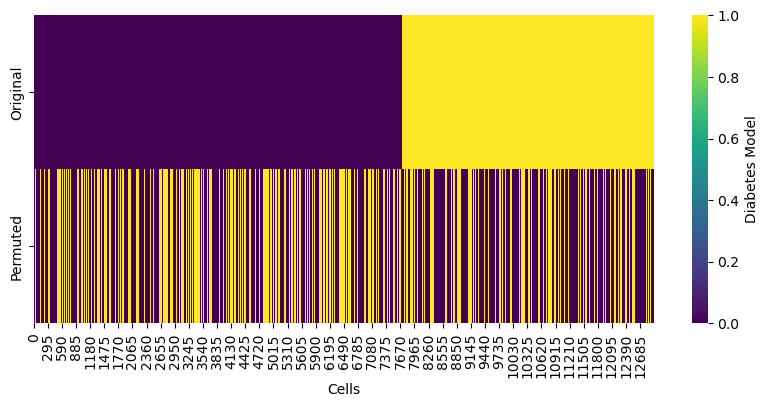

In [9]:
# 作热力图画出 diabetes_model 和 shuffled_diabetes_model 打乱前和打乱后的情况，我想验证打乱确实生效了，即两个标签首先统一变换为 0，1，然后shuffled_diabetes_model按照diabetes_model的顺序排列，但是值是打乱的
import seaborn as sns
import matplotlib.pyplot as plt
# 将标签转换为数值
label_mapping = {'Healthy': 0, 'T2D_dbdb': 1}
beta_adata=adata[(adata.obs['cell_type'] == 'beta') & (adata.obs['diabetes_model'].isin(['Healthy', 'T2D_dbdb']))]
diabetes_model_numeric = beta_adata.obs['diabetes_model'].map(label_mapping).values
shuffled_model_numeric = beta_adata.obs['shuffled_diabetes_model'].map(label_mapping).values

# 创建一个数据矩阵用于热力图，堆叠后按照diabetes_model_numeric的 0，1顺序从小到大排列
sorted_indices = np.argsort(diabetes_model_numeric)
sorted_diabetes_model = diabetes_model_numeric[sorted_indices]
sorted_shuffled_model = shuffled_model_numeric[sorted_indices]
data_matrix = np.vstack([sorted_diabetes_model, sorted_shuffled_model])

# 绘制热力图
plt.figure(figsize=(10, 4))
sns.heatmap(data_matrix, cmap='viridis', cbar_kws={'label': 'Diabetes Model'}, yticklabels=['Original', 'Permuted'])
plt.xlabel('Cells')

# # legend for color bar, only two ticks: 0 and 1, labeled as Healthy and T2D_dbdb
# cbar = plt.gca().collections[0].colorbar
# cbar.set_ticks([0.25, 0.75])
# cbar.set_ticklabels(['Healthy', 'T2D_dbdb'])


plt.savefig('diabetes_model_vs_shuffled_heatmap.pdf',)
plt.show()

In [27]:
adata.write_h5ad('db_pancreas_cells.h5ad')